<a href="https://colab.research.google.com/github/IanSayagnon1/midterm-summer/blob/main/Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sample_logs.csv to sample_logs (1).csv

 Dataset Preview


,id,operation_type,status_code,status_group,message,created_at
0,1,CREATE,200,2xx Success,Operation successful,2026-01-01 00:00:00
1,2,READ,201,2xx Success,Operation successful,2026-01-01 01:00:00
2,3,UPDATE,202,2xx Success,Operation successful,2026-01-01 02:00:00
3,4,DELETE,203,2xx Success,Operation successful,2026-01-01 03:00:00
4,5,CREATE,204,2xx Success,Operation successful,2026-01-01 04:00:00



 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              100 non-null    int64 
 1   operation_type  100 non-null    object
 2   status_code     100 non-null    int64 
 3   status_group    100 non-null    object
 4   message         100 non-null    object
 5   created_at      100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
None

 missing values
id                0
operation_type    0
status_code       0
status_group      0
message           0
created_at        0
dtype: int64

 Total Records
100
-----------------------------------------------------------------------------------------------------------------------------------------------------

 performance Metrics
Total Operations: 100
Successful Operations: 70
Client Errors (4xx): 20
Server Errors (5xx): 10
Total Errors: 30
Success Rate:

,created_at,total_operations,successful_operations,client_errors,server_errors,total_errors,success_rate,error_rate
0,01/01/26,24,18,4,2,6,75.000000,25.000000
1,01/02/26,24,17,5,2,7,70.833333,29.166667
2,01/03/26,24,16,5,3,8,66.666667,33.333333
3,01/04/26,24,18,4,2,6,75.000000,25.000000
4,01/05/26,4,1,2,1,3,25.000000,75.000000


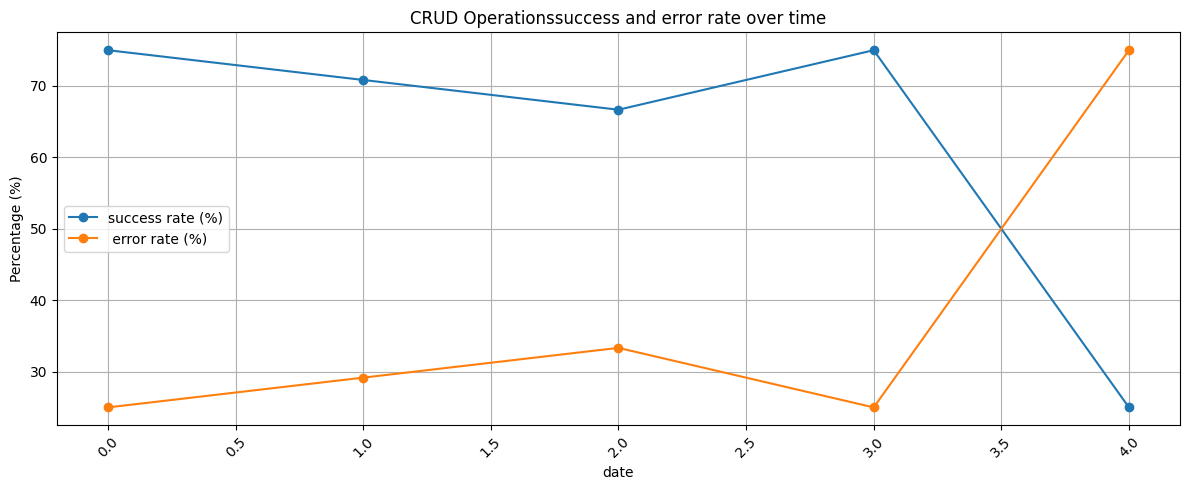

,total_operations,successful_operations,success_rate,error_rate
operation_type,,,,
CREATE,25,20,80.0,20.0
DELETE,25,15,60.0,40.0
READ,25,15,60.0,40.0
UPDATE,25,20,80.0,20.0


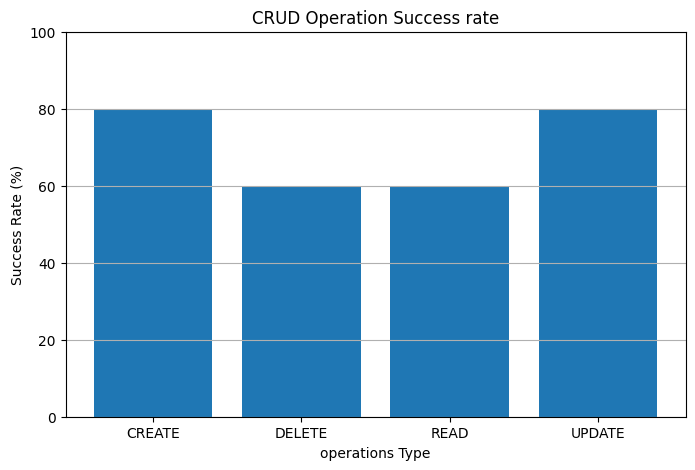


HTTP Response Distribution


,0
status_code,
200,20
201,20
202,10
203,10
204,10
400,2
401,4
402,3
403,2


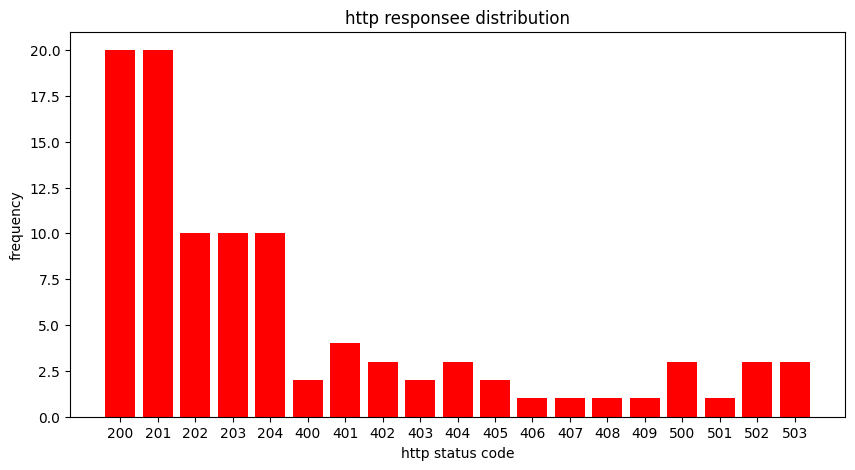

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

#upload csv
Uploaded = files.upload()
filename = list(Uploaded.keys())[0]

#load dataset
df = pd.read_csv(filename)
print("\n Dataset Preview")
display(df.head())

#data Validation
print("\n Dataset Information")
print (df.info())
print("\n missing values")
print (df.isnull().sum())
print("\n Total Records")
print(len(df))

#convert timestamp
df['created_at']=pd.to_datetime(df["created_at"])

#http responses
df['success']=df['status_code'].between(200, 299)
df['client_error']=df['status_code'].between(400, 499)
df['server_error']=df['status_code'].between(500, 599)

#performance metrics
total_operations=len(df)
successful_operations=df['success'].sum()
client_errors=df['client_error'].sum()
server_errors=df['server_error'].sum()
total_errors=client_errors + server_errors
success_rate = (successful_operations/total_operations) * 100
error_rate = (total_errors/total_operations) * 100

print("-----------------------------------------------------------------------------------------------------------------------------------------------------")
print("\n performance Metrics")
print("Total Operations:",total_operations)
print("Successful Operations:",successful_operations)
print("Client Errors (4xx):",client_errors)
print("Server Errors (5xx):",server_errors)
print("Total Errors:",total_errors)
print(f"Success Rate: {success_rate:.2f}%")
print(f"Error Rate:{error_rate:.2f}%")

#Time Series
daily_metrics = df.groupby(df['created_at'].dt.strftime('%m/%d/%y')).agg(
    total_operations=('id', 'count'),
    successful_operations=('success', 'sum'),
    client_errors=('client_error', 'sum'),
    server_errors=('server_error', 'sum')
).reset_index()

daily_metrics['total_errors'] = daily_metrics['client_errors'] + daily_metrics['server_errors']
daily_metrics['success_rate'] = (daily_metrics['successful_operations'] / daily_metrics['total_operations']) * 100
daily_metrics['error_rate'] = (daily_metrics['total_errors'] / daily_metrics['total_operations']) * 100

print("\n Daily Time-Series Metrics ")
display(daily_metrics.head())

#plot time series

plt.figure(figsize=(12,5))
plt.plot(
    daily_metrics.index,
    daily_metrics['success_rate'],
    marker= 'o',
    label ="success rate (%)"
)

plt.plot(
    daily_metrics.index,
    daily_metrics['error_rate'],
    marker= 'o',
    label =" error rate (%)"
)

plt.title("CRUD Operationssuccess and error rate over time")
plt.xlabel("date")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#CRUD count

crud_metrics = df.groupby('operation_type').agg(
    total_operations=('id','count'),
    successful_operations = ('success','sum')
)

crud_metrics['success_rate'] = (crud_metrics['successful_operations']/crud_metrics ['total_operations']) * 100
crud_metrics['error_rate'] = (100-crud_metrics['success_rate'])
display(crud_metrics)
# CRUD Count Bar Chart
plt.figure(figsize=(8,5))
plt.bar(crud_metrics.index,crud_metrics['success_rate'])
plt.title("CRUD Operation Success rate")
plt.xlabel("operations Type")
plt.ylabel("Success Rate (%)")
plt.ylim(0,100)
plt.grid(axis='y')
plt.show()

#HTTP Response Distribution
http_distribution = df.groupby('status_code'). size()
print("\nHTTP Response Distribution")
display(http_distribution)

plt.figure(figsize=(10,5))
plt.bar(
     http_distribution.index.astype(str),
     http_distribution.values,
     color= 'Red'
)
plt.title("http responsee distribution")
plt.xlabel("http status code")
plt.ylabel("frequency")
plt.show()
